# 08 — Master Comparison: All 6 Models
The final notebook. Loads every model's saved predictions and produces:
1. Overall accuracy & F1 leaderboard
2. Heatmaps — accuracy by volatility regime (Low / High)
3. Heatmaps — accuracy by period regime (Pre-COVID / COVID / Post-COVID)
4. Unified cumulative backtest (all models on one chart)
5. Regime-specific backtests
6. Final summary table with alpha over buy-and-hold

**Models:** ARIMA → ARIMAX → XGBoost → Random Forest → LSTM

## Setup

In [1]:
from google.colab import files
files.upload()

Saving preds_lstm_ag.csv to preds_lstm_ag.csv
Saving preds_lstm_au.csv to preds_lstm_au.csv
Saving preds_rf_ag.csv to preds_rf_ag.csv
Saving preds_rf_au.csv to preds_rf_au.csv
Saving preds_xgb_ag.csv to preds_xgb_ag.csv
Saving preds_xgb_au.csv to preds_xgb_au.csv
Saving preds_arima_ag.csv to preds_arima_ag.csv
Saving preds_arima_au.csv to preds_arima_au.csv
Saving preds_arimax_ag.csv to preds_arimax_ag.csv
Saving preds_arimax_au.csv to preds_arimax_au.csv
Saving gold_silver_final.csv to gold_silver_final.csv
Saving gold_silver_garch.csv to gold_silver_garch.csv


{'preds_lstm_ag.csv': b'Date,actual,pred,prob,ag_returns,vol_regime,period_regime\n2021-08-02,1,0,0.5116036,0.0011353364881268,low_vol,covid\n2021-08-03,0,0,0.51121634,0.0003521224667419,low_vol,covid\n2021-08-04,0,0,0.5121953,-0.0047048170090922,low_vol,covid\n2021-08-05,0,0,0.5122124,-0.0066636178867014,low_vol,covid\n2021-08-06,0,0,0.5127556,-0.0389248413414774,low_vol,covid\n2021-08-09,1,0,0.5140047,-0.0444499403239592,low_vol,covid\n2021-08-10,1,0,0.5138165,0.0052325410186479,high_vol,covid\n2021-08-11,0,0,0.51270175,0.0041407977233134,high_vol,covid\n2021-08-12,1,0,0.51158005,-0.0158444408198132,high_vol,covid\n2021-08-13,1,0,0.5117547,0.0282910988846559,high_vol,covid\n2021-08-16,0,0,0.50966245,0.0005047967429867,high_vol,covid\n2021-08-17,0,0,0.50889367,-0.0055663450451756,high_vol,covid\n2021-08-18,0,0,0.5094849,-0.0100298356381186,high_vol,covid\n2021-08-19,0,0,0.5096544,-0.0082347927558088,high_vol,covid\n2021-08-20,1,0,0.5102741,-0.0049649221885396,high_vol,covid\n2021-08-2

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.dpi"] = 115
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False


In [3]:
COLORS = {
    "ARIMA"        : "#457B9D",
    "ARIMAX"       : "#1D3557",
    "Logistic Reg" : "#A8DADC",
    "XGBoost"      : "#E63946",
    "Random Forest": "#2A9D8F",
    "LSTM"         : "#9B5DE5",
}


## 1. Load All Predictions

In [4]:
preds = {
    "ARIMA": {
        "au": pd.read_csv("preds_arima_au.csv",    index_col=0, parse_dates=True),
        "ag": pd.read_csv("preds_arima_ag.csv",    index_col=0, parse_dates=True),
    },
    "ARIMAX": {
        "au": pd.read_csv("preds_arimax_au.csv",   index_col=0, parse_dates=True),
        "ag": pd.read_csv("preds_arimax_ag.csv",   index_col=0, parse_dates=True),
    },
    "XGBoost": {
        "au": pd.read_csv("preds_xgb_au.csv",      index_col=0, parse_dates=True),
        "ag": pd.read_csv("preds_xgb_ag.csv",      index_col=0, parse_dates=True),
    },
    "Random Forest": {
        "au": pd.read_csv("preds_rf_au.csv",       index_col=0, parse_dates=True),
        "ag": pd.read_csv("preds_rf_ag.csv",       index_col=0, parse_dates=True),
    },
    "LSTM": {
        "au": pd.read_csv("preds_lstm_au.csv",     index_col=0, parse_dates=True),
        "ag": pd.read_csv("preds_lstm_ag.csv",     index_col=0, parse_dates=True),
    },
}

# Normalise return column names
RC = {"au": "au_returns", "ag": "ag_returns"}
for model_name, d in preds.items():
    for key in ["au","ag"]:
        df_m = d[key]
        if RC[key] in df_m.columns and "returns" not in df_m.columns:
            df_m["returns"] = df_m[RC[key]]

for m, d in preds.items():
    print(f"{m:15s} | Gold {len(d["au"])} rows | Silver {len(d["ag"])} rows")


ARIMA           | Gold 1227 rows | Silver 1227 rows
ARIMAX          | Gold 1227 rows | Silver 1227 rows
XGBoost         | Gold 1227 rows | Silver 1227 rows
Random Forest   | Gold 1227 rows | Silver 1227 rows
LSTM            | Gold 1222 rows | Silver 1222 rows


## 2. Overall Leaderboard

=== OVERALL LEADERBOARD ===
        Model  Asset  Accuracy     F1
Random Forest   Gold    0.5599 0.5122
      XGBoost   Gold    0.5452 0.5017
        ARIMA   Gold    0.5444 0.3927
       ARIMAX   Gold    0.5216 0.4927
         LSTM   Gold    0.5000 0.5011
Random Forest Silver    0.5379 0.5005
      XGBoost Silver    0.5192 0.4480
        ARIMA Silver    0.5118 0.3785
       ARIMAX Silver    0.5094 0.5095
         LSTM Silver    0.5016 0.5019


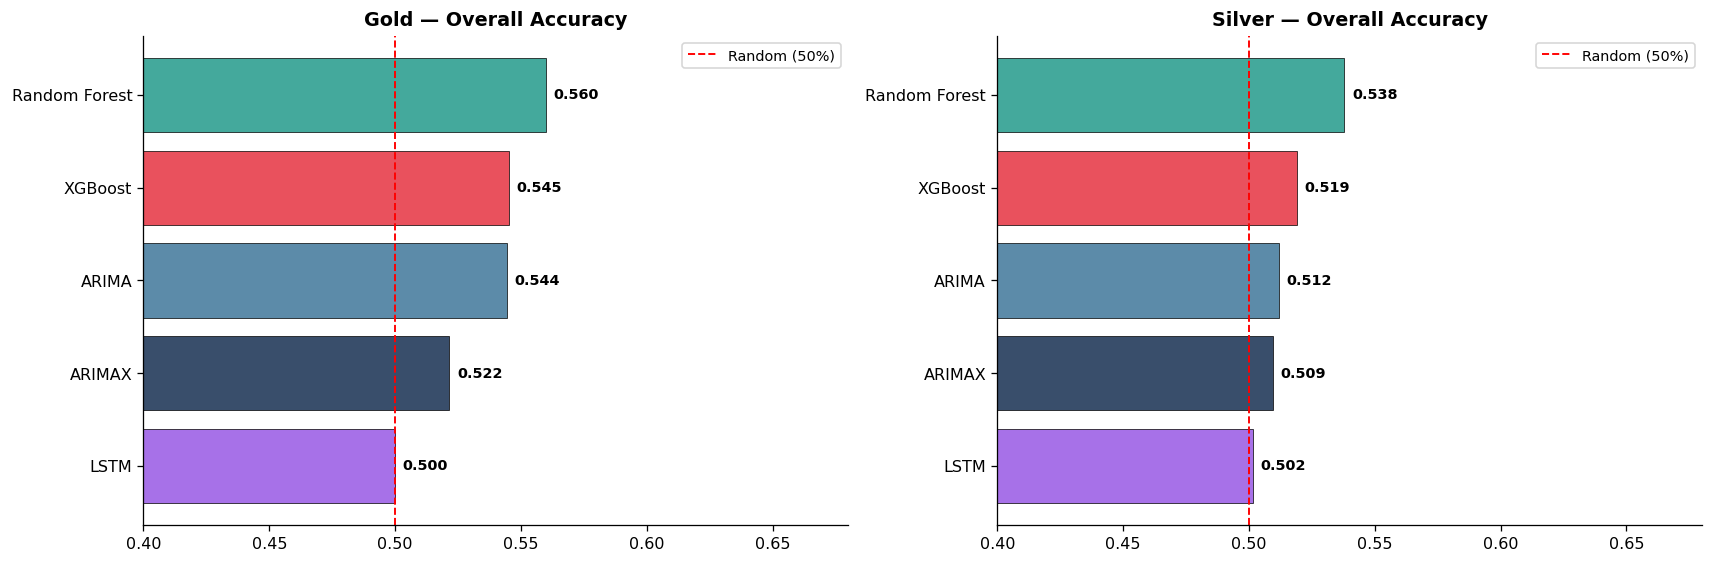

In [5]:
rows = []
for model_name, d in preds.items():
    for asset, key in [("Gold","au"), ("Silver","ag")]:
        df_m = d[key].dropna(subset=["actual","pred"])
        acc  = accuracy_score(df_m["actual"], df_m["pred"])
        f1   = f1_score(df_m["actual"], df_m["pred"], average="weighted", zero_division=0)
        rows.append({"Model": model_name, "Asset": asset,
                     "Accuracy": round(acc,4), "F1": round(f1,4)})

lb = pd.DataFrame(rows)
print("=== OVERALL LEADERBOARD ===")
print(lb.sort_values(["Asset","Accuracy"], ascending=[True,False]).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, asset in zip(axes, ["Gold", "Silver"]):
    sub    = lb[lb["Asset"]==asset].sort_values("Accuracy", ascending=True)
    colors = [COLORS[m] for m in sub["Model"]]
    bars   = ax.barh(sub["Model"], sub["Accuracy"], color=colors, alpha=0.88,
                     edgecolor="black", linewidth=0.5)
    ax.axvline(0.50, color="red", linestyle="--", linewidth=1.2, label="Random (50%)")
    ax.set_xlim(0.40, 0.68)
    ax.set_title(f"{asset} — Overall Accuracy", fontweight="bold", fontsize=12)
    ax.legend(fontsize=9)
    for bar, val in zip(bars, sub["Accuracy"]):
        ax.text(val+0.003, bar.get_y()+bar.get_height()/2,
                f"{val:.3f}", va="center", fontsize=9, fontweight="bold")
plt.tight_layout()
plt.show()


## 3. Regime Accuracy Heatmaps

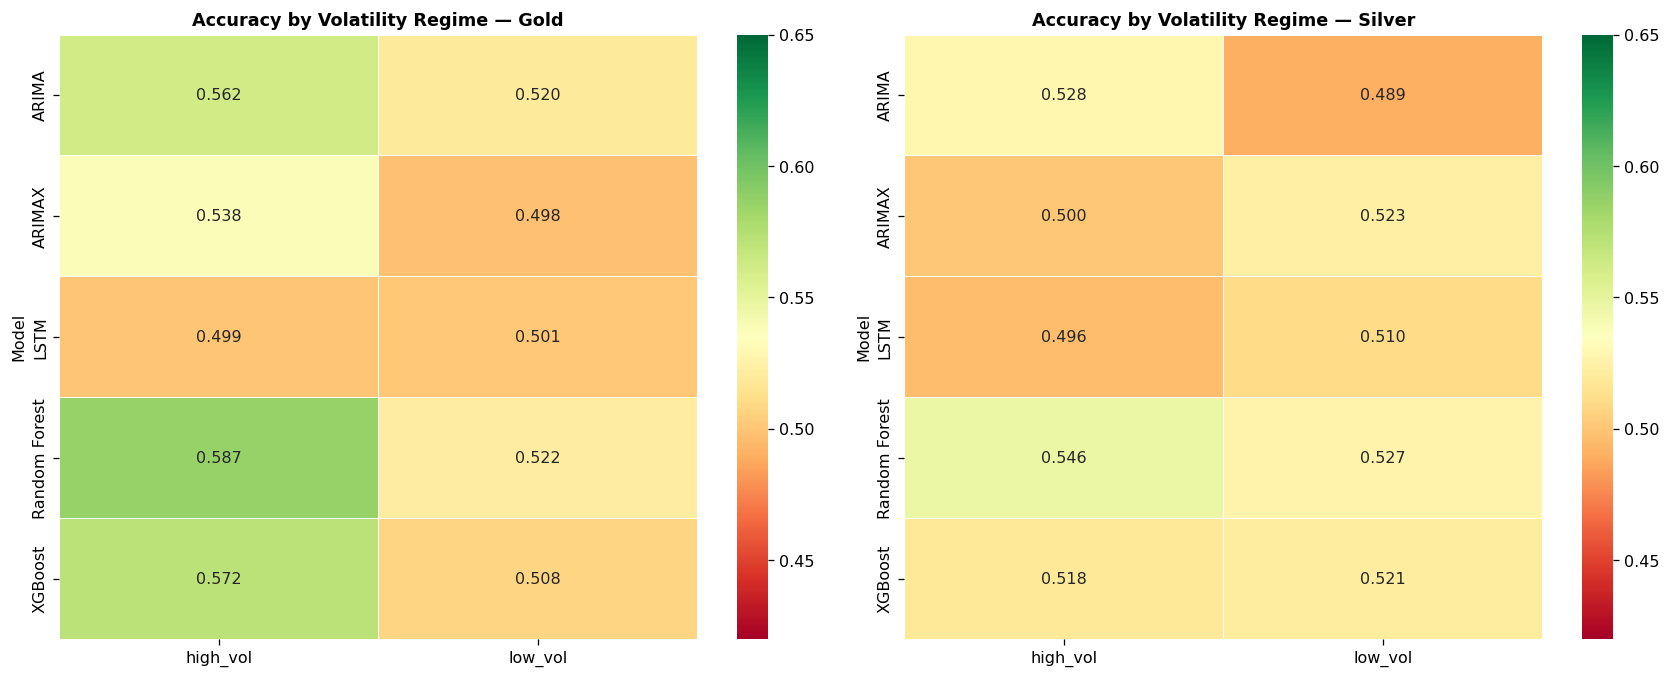

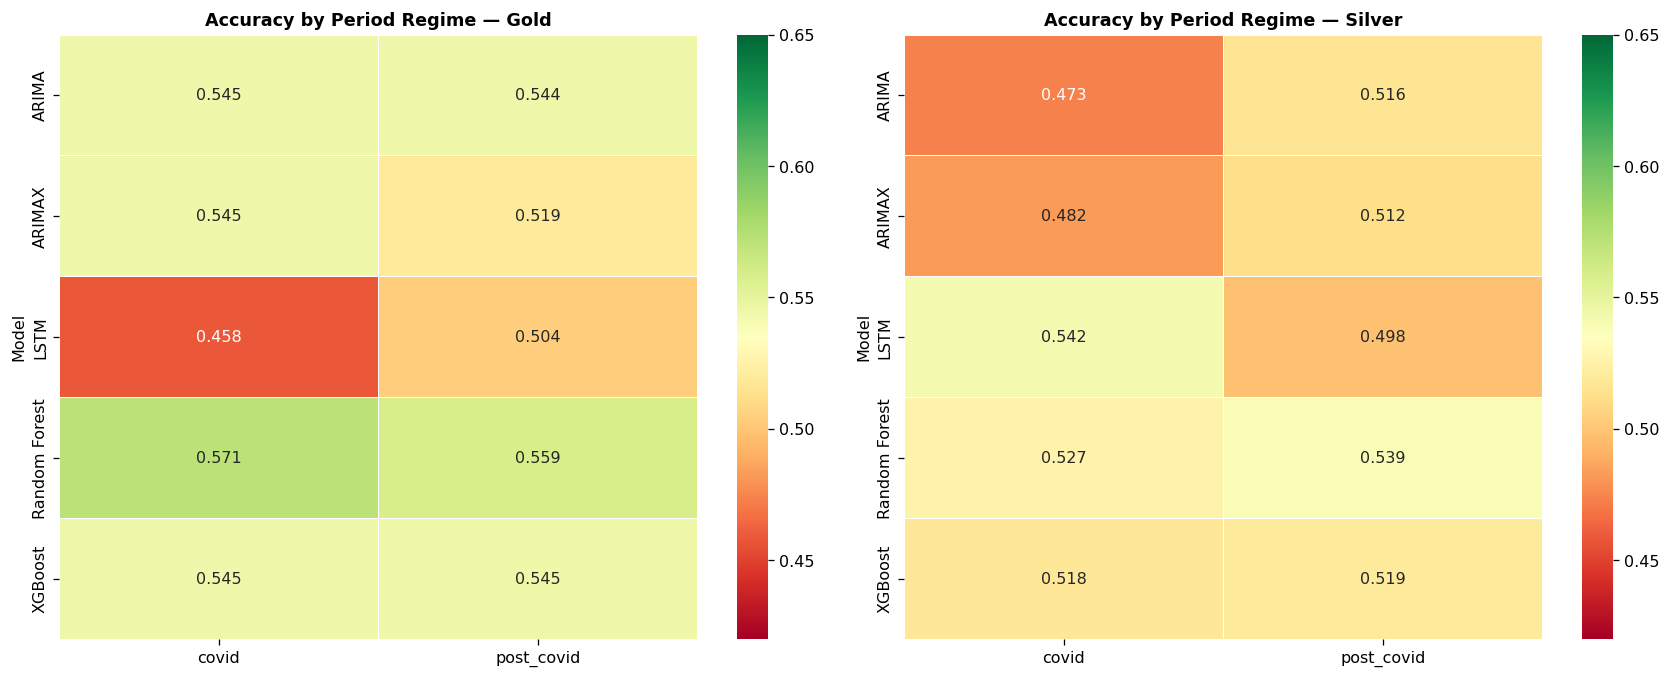

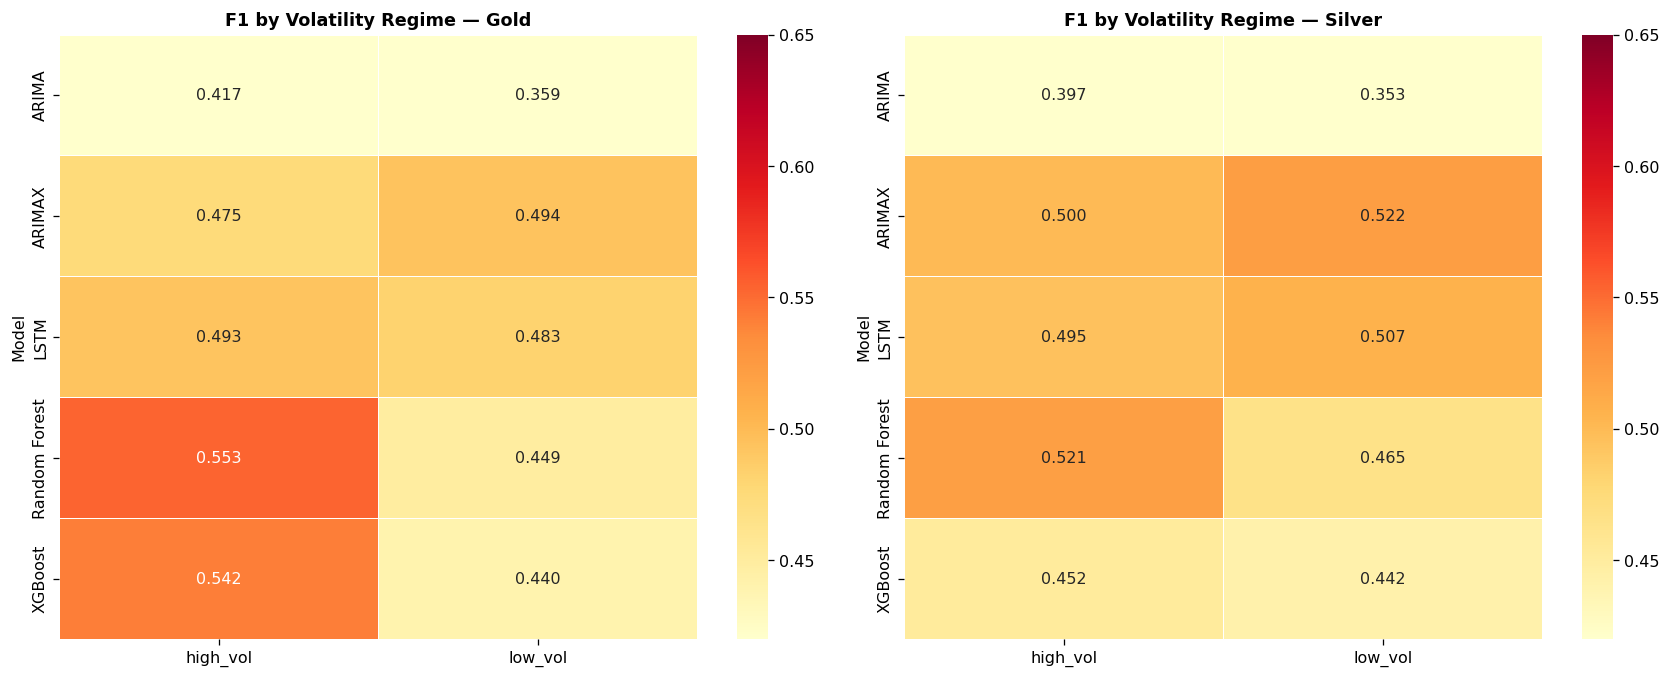

In [6]:
def build_regime_lb(preds_dict, regime_col):
    rows = []
    for model_name, d in preds_dict.items():
        for asset, key in [("Gold","au"), ("Silver","ag")]:
            df_m = d[key].dropna(subset=["actual","pred"])
            if regime_col not in df_m.columns: continue
            for regime in sorted(df_m[regime_col].unique()):
                sub = df_m[df_m[regime_col]==regime]
                if len(sub) < 5: continue
                acc = accuracy_score(sub["actual"], sub["pred"])
                f1  = f1_score(sub["actual"], sub["pred"], average="weighted", zero_division=0)
                rows.append({"Model": model_name, "Asset": asset,
                             "Regime": regime, "Accuracy": acc, "F1": f1})
    return pd.DataFrame(rows)

def plot_heatmap(lb_df, value_col, suptitle, cmap, vmin, vmax):
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    for ax, asset in zip(axes, ["Gold","Silver"]):
        sub = lb_df[lb_df["Asset"]==asset]
        if sub.empty: continue
        pivot = sub.pivot(index="Model", columns="Regime", values=value_col)
        pivot = pivot.loc[list(COLORS.keys()) if all(m in pivot.index for m in COLORS) else pivot.index]
        sns.heatmap(pivot, annot=True, fmt=".3f", cmap=cmap,
                    vmin=vmin, vmax=vmax, linewidths=0.6, ax=ax, square=False)
        ax.set_title(f"{suptitle} — {asset}", fontweight="bold", fontsize=11)
        ax.set_xlabel("")
    plt.tight_layout()
    plt.show()

vol_lb    = build_regime_lb(preds, "vol_regime")
period_lb = build_regime_lb(preds, "period_regime")

plot_heatmap(vol_lb,    "Accuracy", "Accuracy by Volatility Regime", "RdYlGn", 0.42, 0.65)
plot_heatmap(period_lb, "Accuracy", "Accuracy by Period Regime",     "RdYlGn", 0.42, 0.65)
plot_heatmap(vol_lb,    "F1",       "F1 by Volatility Regime",       "YlOrRd", 0.42, 0.65)


## 4. Unified Backtest — All 6 Models

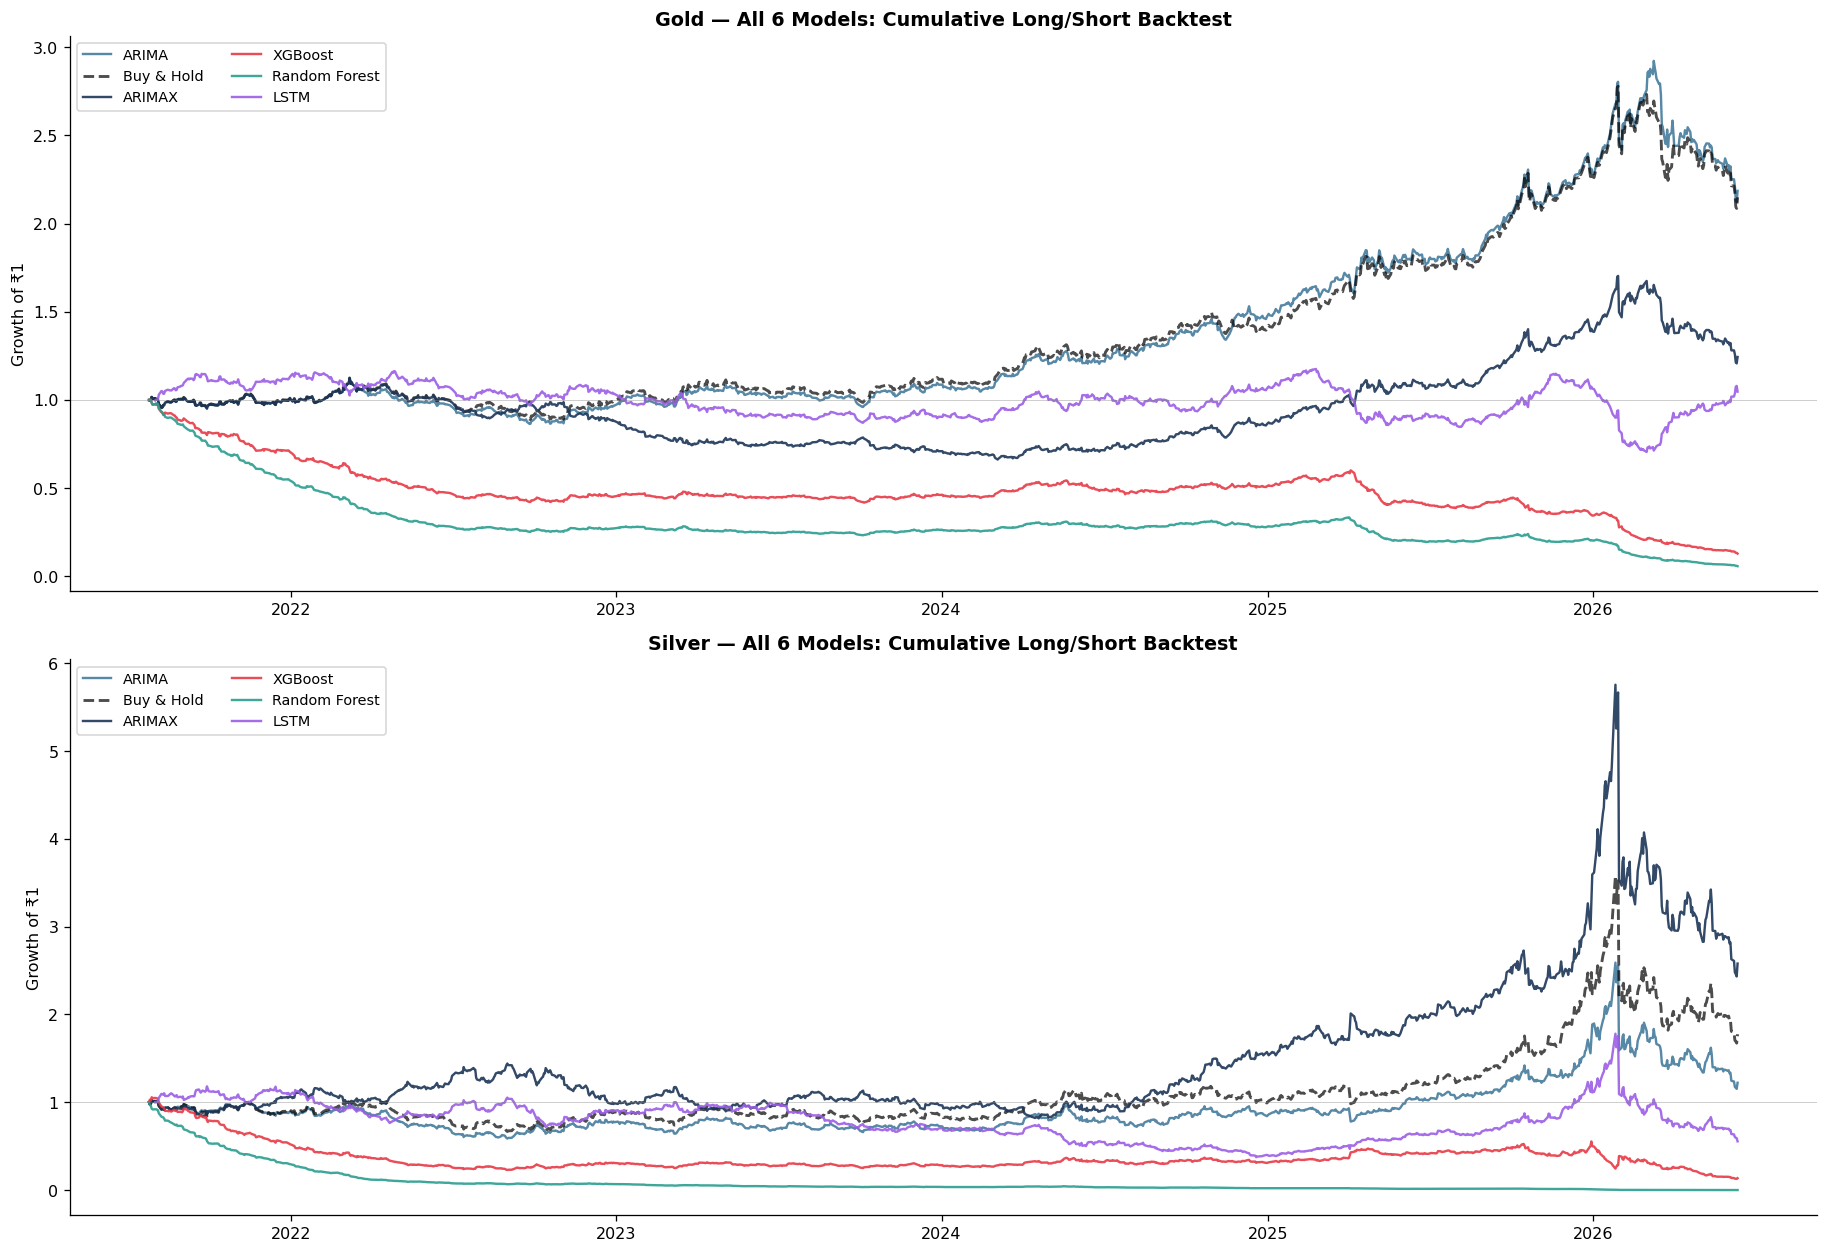

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(16, 11))

for ax, (asset, key) in zip(axes, [("Gold","au"), ("Silver","ag")]):
    bh_done = False
    for model_name, d in preds.items():
        df_m = d[key].dropna(subset=["actual","pred"])
        r_col = next((c for c in ["returns","au_returns","ag_returns"]
                      if c in df_m.columns), None)
        if r_col is None: continue
        df_m = df_m.dropna(subset=[r_col])
        signal    = np.where(df_m["pred"]==1, 1, -1)
        cum_strat = (1 + signal * df_m[r_col]).cumprod()
        cum_bh    = (1 + df_m[r_col]).cumprod()
        ax.plot(df_m.index, cum_strat, label=model_name,
                color=COLORS[model_name], linewidth=1.5, alpha=0.9)
        if not bh_done:
            ax.plot(df_m.index, cum_bh, "k--", linewidth=1.8, alpha=0.7, label="Buy & Hold")
            bh_done = True
    ax.axhline(1, color="gray", linewidth=0.6, alpha=0.4)
    ax.set_title(f"{asset} — All 6 Models: Cumulative Long/Short Backtest",
                 fontweight="bold", fontsize=12)
    ax.set_ylabel("Growth of ₹1")
    ax.legend(loc="upper left", fontsize=9, ncol=2)

plt.tight_layout()
plt.show()


## 5. Regime-Specific Backtests

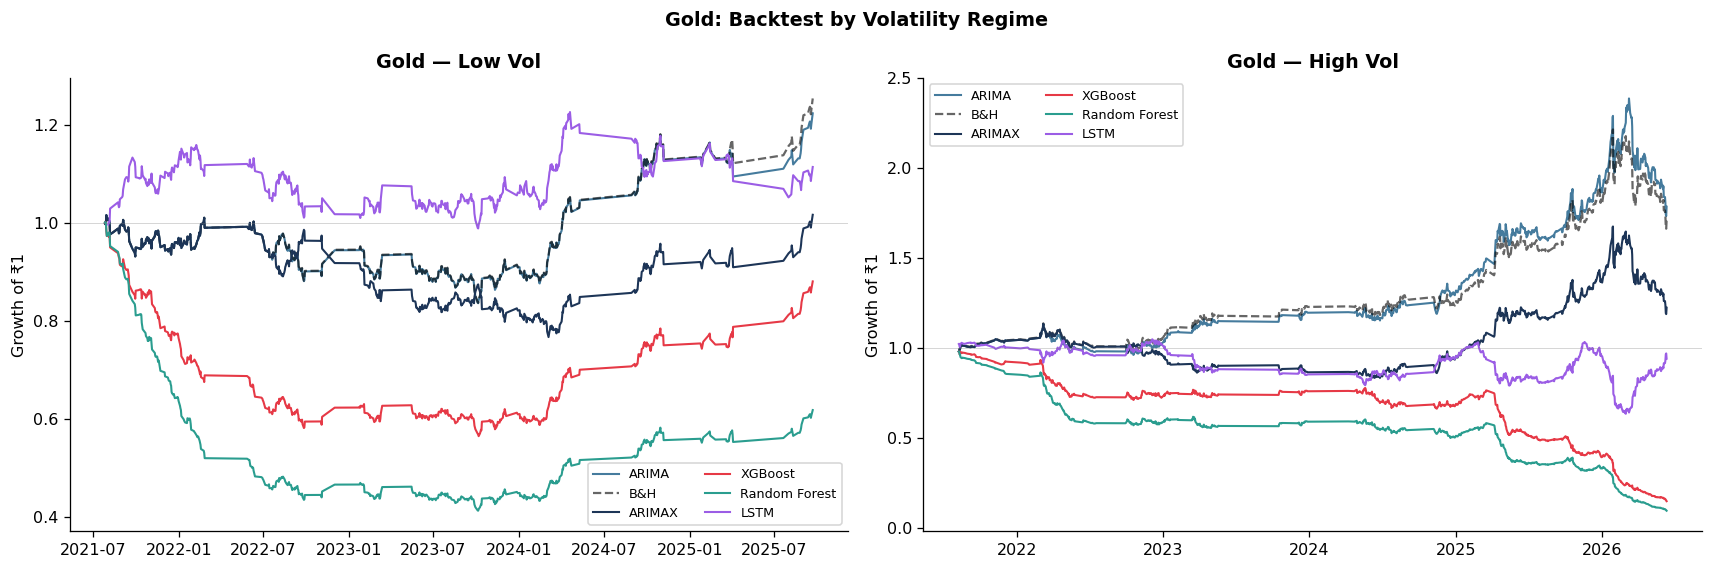

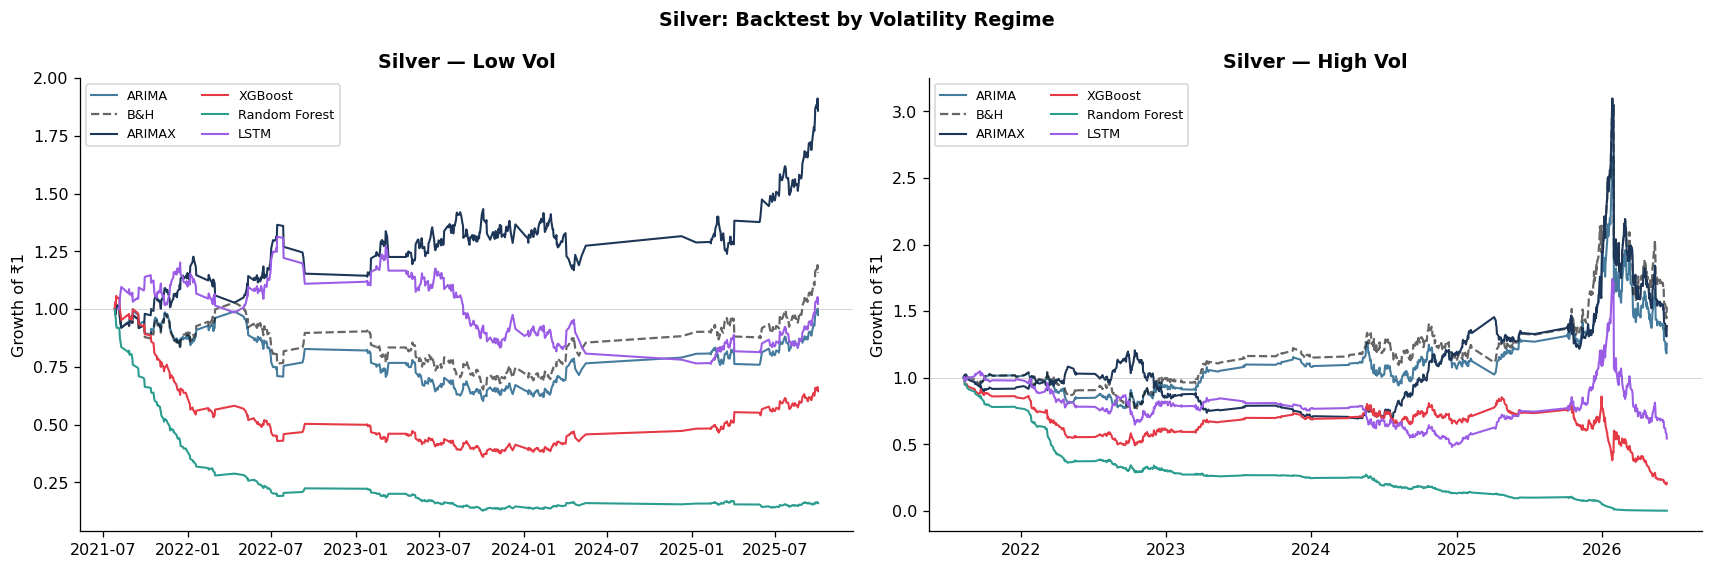

In [8]:
for asset, key in [("Gold","au"), ("Silver","ag")]:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    for ax, regime in zip(axes, ["low_vol","high_vol"]):
        bh_done = False
        for model_name, d in preds.items():
            df_m = d[key].dropna(subset=["actual","pred"])
            if "vol_regime" not in df_m.columns: continue
            r_col = next((c for c in ["returns","au_returns","ag_returns"]
                          if c in df_m.columns), None)
            if r_col is None: continue
            sub = df_m[df_m["vol_regime"]==regime].dropna(subset=[r_col])
            if len(sub) < 5: continue
            signal    = np.where(sub["pred"]==1, 1, -1)
            cum_strat = (1 + signal * sub[r_col]).cumprod()
            cum_bh    = (1 + sub[r_col]).cumprod()
            ax.plot(sub.index, cum_strat, label=model_name,
                    color=COLORS[model_name], linewidth=1.3)
            if not bh_done:
                ax.plot(sub.index, cum_bh, "k--", linewidth=1.4, alpha=0.6, label="B&H")
                bh_done = True
        ax.axhline(1, color="gray", linewidth=0.5, alpha=0.4)
        ax.set_title(f"{asset} — {regime.replace("_"," ").title()}",
                     fontweight="bold")
        ax.set_ylabel("Growth of ₹1")
        ax.legend(fontsize=8, ncol=2)
    plt.suptitle(f"{asset}: Backtest by Volatility Regime", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()


## 6. Final Summary Table

In [9]:
summary_rows = []
for model_name, d in preds.items():
    for asset, key in [("Gold","au"), ("Silver","ag")]:
        df_m = d[key].dropna(subset=["actual","pred"])
        r_col = next((c for c in ["returns","au_returns","ag_returns"]
                      if c in df_m.columns), None)
        if r_col is None: continue
        df_m = df_m.dropna(subset=[r_col])
        signal   = np.where(df_m["pred"]==1, 1, -1)
        strat_r  = (1 + signal * df_m[r_col]).cumprod().iloc[-1] - 1
        bh_r     = (1 + df_m[r_col]).cumprod().iloc[-1] - 1
        acc      = accuracy_score(df_m["actual"], df_m["pred"])
        f1       = f1_score(df_m["actual"], df_m["pred"], average="weighted", zero_division=0)
        hit      = (signal == np.sign(df_m[r_col].values)).mean()
        summary_rows.append({
            "Model":    model_name,
            "Asset":    asset,
            "Accuracy": round(acc,  4),
            "F1":       round(f1,   4),
            "Hit Rate": round(hit,  4),
            "Strat Ret": f"{strat_r:+.1%}",
            "B&H Ret":   f"{bh_r:+.1%}",
            "Alpha":     f"{strat_r-bh_r:+.1%}",
        })

summary = pd.DataFrame(summary_rows)
print("=== FINAL SUMMARY TABLE — ALL 6 MODELS ===")
print(summary.to_string(index=False))

print("\n=== WINNER PER ASSET ===")
for asset in ["Gold","Silver"]:
    sub = summary[summary["Asset"]==asset]
    print(f"\n  {asset}:")
    print(f"    Best Accuracy → {sub.loc[sub['Accuracy'].idxmax(), 'Model']}")
    print(f"    Best F1       → {sub.loc[sub['F1'].idxmax(), 'Model']}")


=== FINAL SUMMARY TABLE — ALL 6 MODELS ===
        Model  Asset  Accuracy     F1  Hit Rate Strat Ret B&H Ret   Alpha
        ARIMA   Gold    0.5444 0.3927    0.5428   +118.5% +114.9%   +3.7%
        ARIMA Silver    0.5118 0.3785    0.5143    +22.2%  +77.5%  -55.3%
       ARIMAX   Gold    0.5216 0.4927    0.5306    +24.4% +114.9%  -90.5%
       ARIMAX Silver    0.5094 0.5095    0.5249   +158.0%  +77.5%  +80.5%
      XGBoost   Gold    0.5452 0.5017    0.4450    -87.1% +114.9% -201.9%
      XGBoost Silver    0.5192 0.4480    0.4360    -86.5%  +77.5% -163.9%
Random Forest   Gold    0.5599 0.5122    0.4189    -94.2% +114.9% -209.1%
Random Forest Silver    0.5379 0.5005    0.3423   -100.0%  +77.5% -177.5%
         LSTM   Gold    0.5000 0.5011    0.5016     +4.7% +113.6% -108.9%
         LSTM Silver    0.5016 0.5019    0.5115    -44.5%  +75.5% -120.0%

=== WINNER PER ASSET ===

  Gold:
    Best Accuracy → Random Forest
    Best F1       → Random Forest

  Silver:
    Best Accuracy → Random Fo

## Conclusion
**Research question answered:**
> *Which model — across Low-Vol and High-Vol regimes — most reliably predicts next-day direction of Gold and Silver returns, and does following that signal generate alpha over buy-and-hold?*

**What to read from the results:**
- Heatmap rows where one model clearly leads → that model has a structural edge in that regime
- ARIMAX > ARIMA in any regime → macro variables (VIX, rates, USD) carry directional information
- Strategy Ret > B&H Ret → the model's signal generates alpha, not just noise
- COVID period accuracy drop across all models → expected; no model trained pre-COVID can anticipate a structural break
